# Stage 1 - At Rest PPG (Student Version)

Goal: do a clean baseline pipeline on one still file and get HR + HRV.

What I do in this notebook:
- load one still PPG file + IMU file
- bandpass filter green channel
- detect beats
- compute HR, SDNN, RMSSD, pNN50, LF/HF
- compare quickly with HeartPy only if I enable it

Dataset choice in this notebook: `P26`, `left ear`, `still` condition.

In [74]:
import importlib.util
required = ['numpy', 'scipy', 'pandas', 'matplotlib' , 'pyPPG', 'heartpy']
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    raise ImportError(
        f"Missing required packages: {missing}."
    )
print(f'Core packages {required} are available.')

Core packages ['numpy', 'scipy', 'pandas', 'matplotlib', 'pyPPG', 'heartpy'] are available.


In [70]:
from pathlib import Path

dataset_dir = Path('Dataset')

if not dataset_dir.exists():
    raise FileNotFoundError(
        'Dataset folder not found. Put the extracted Dataset folder in assignment_2 and re-run.'
    )

print('Dataset ready at', dataset_dir.resolve())

Dataset ready at /home/odin/achal/Pervasive-Computing-for-Health/assignment_2/Dataset


## Section 1: Import Libraries and Set Paths

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

dataset_path = Path('./Dataset')
participant_id = '26'
ear = 'left'

print(f'Dataset path: {dataset_path.resolve()}')
print(f'Participant: P{participant_id}, ear: {ear}')

Dataset path: /home/odin/achal/Pervasive-Computing-for-Health/assignment_2/Dataset
Participant: P26, ear: left


## Load + quick check

I check:
- sample rate from timestamps
- basic ranges
- first 60 s plot to see noise/artifacts

This is enough before filtering.

In [50]:
# Load PPG data
ppg_file = dataset_path / f'P{participant_id}' / 'EARBUDS' / f'{participant_id}-still-ppg-{ear}.csv'
ppg_data = pd.read_csv(ppg_file)

print("PPG Data Summary:")
print(ppg_data.head())
print(f"\nShape: {ppg_data.shape}")
print(f"Columns: {ppg_data.columns.tolist()}")
print(f"\nBasic statistics:")
print(ppg_data.describe())

# Set sampling frequency
fs = 100  # EarSet PPG sampling rate
ppg_duration = len(ppg_data) / fs
print(f"\nSampling frequency: {fs} Hz")
print(f"Total duration: {ppg_duration:.1f} seconds ({ppg_duration/60:.1f} minutes)")

PPG Data Summary:
       timestamp  green      ir       red
0  1637236176282  30173   52128   52208.0
1  1637236176292  30155   83553   84982.0
2  1637236176302  30172  115015  116408.0
3  1637236176312  30192  132993  147860.0
4  1637236176322  30194  133014  160352.0

Shape: (12003, 4)
Columns: ['timestamp', 'green', 'ir', 'red']

Basic statistics:
                 red
count   12000.000000
mean   241071.289417
std     81966.068555
min     52208.000000
25%    159190.000000
50%    173557.000000
75%    322993.000000
max    324852.000000

Sampling frequency: 100 Hz
Total duration: 120.0 seconds (2.0 minutes)


In [51]:
# Calculate the difference between consecutive timestamps
timestamp_diffs_ms = ppg_data['timestamp'].astype(str).str.replace('#', '').astype(int).diff().dropna()

# Calculate the average difference in milliseconds
average_timestamp_diff_ms = timestamp_diffs_ms.mean()

# Convert average difference to sampling frequency in Hz
# 1 second = 1000 milliseconds
estimated_fs = 1000 / average_timestamp_diff_ms

print(f"Average difference between consecutive timestamps: {average_timestamp_diff_ms:.2f} ms")
print(f"Estimated sampling rate: {estimated_fs:.2f} Hz")

Average difference between consecutive timestamps: 10.00 ms
Estimated sampling rate: 100.03 Hz


In [52]:
# Load IMU data
imu_file = dataset_path / f'P{participant_id}' / 'EARBUDS' / f'{participant_id}-still-imu-{ear}.csv'
imu_data = pd.read_csv(imu_file)

print("IMU Data Summary:")
print(imu_data.head())
print(f"\nShape: {imu_data.shape}")
print(f"Columns: {imu_data.columns.tolist()}")

IMU Data Summary:
       timestamp    ax    ay     az  gx   gy  gz
0  1637236438564 -5009 -9754  12289  35  149  49
1  1637236438574 -5000 -9744  12275  25  157  45
2  1637236438583 -5009 -9762  12246  18  164  39
3  1637236438593 -5006 -9748  12244  23  170  30
4  1637236438603 -5015 -9722  12250  35  175  23

Shape: (12541, 7)
Columns: ['timestamp', 'ax', 'ay', 'az', 'gx', 'gy', 'gz']


In [53]:
duration_sec = 60
start_sec = 20

start_idx = int(start_sec * fs)
end_idx = int((start_sec + duration_sec) * fs)

ppg_segment = ppg_data.iloc[start_idx:end_idx].copy()
imu_segment = imu_data.iloc[start_idx:end_idx].copy()
time = np.arange(len(ppg_segment)) / fs

print(f'Extracted segment: {start_sec}s to {start_sec + duration_sec}s')
print(f'Segment length: {len(ppg_segment)} samples ({duration_sec}s)')

Extracted segment: 20s to 80s
Segment length: 6000 samples (60s)


## Bandpass filtering (0.5-5 Hz)

Why this range:
- below 0.5 Hz is mostly baseline drift / movement
- above 5 Hz is mostly noise for this task

I keep it simple with a Butterworth bandpass.

In [54]:
# Design Butterworth bandpass filter
# Standard for PPG: 0.5-5 Hz (cardiac frequency range)

low_cutoff = 0.5   # Hz
high_cutoff = 5.0  # Hz
filter_order = 4

# Normalize frequencies to Nyquist frequency
nyquist_freq = fs / 2
low_normalized = low_cutoff / nyquist_freq
high_normalized = high_cutoff / nyquist_freq

# Design filter using second-order sections (more numerically stable)
sos = signal.butter(filter_order, [low_normalized, high_normalized],
                    btype='band', output='sos')

# Apply filter to green PPG signal
# Ensure the 'green' column is numeric, handling potential non-numeric values
ppg_segment['green'] = pd.to_numeric(ppg_segment['green'], errors='coerce')
# Fill any NaN values that might have been introduced by coercion (e.g., from 'current:32ma')
ppg_segment['green'] = ppg_segment['green'].interpolate(method='linear', limit_direction='both')
ppg_green = ppg_segment['green'].values.astype(float) # Convert to float
ppg_filtered = signal.sosfilt(sos, ppg_green)

print(f"Filter Design:")
print(f"  Type: Butterworth bandpass")
print(f"  Order: {filter_order}")
print(f"  Cutoff frequencies: {low_cutoff}-{high_cutoff} Hz")
print(f"  Normalized frequencies: {low_normalized:.3f}-{high_normalized:.3f}")

Filter Design:
  Type: Butterworth bandpass
  Order: 4
  Cutoff frequencies: 0.5-5.0 Hz
  Normalized frequencies: 0.010-0.100


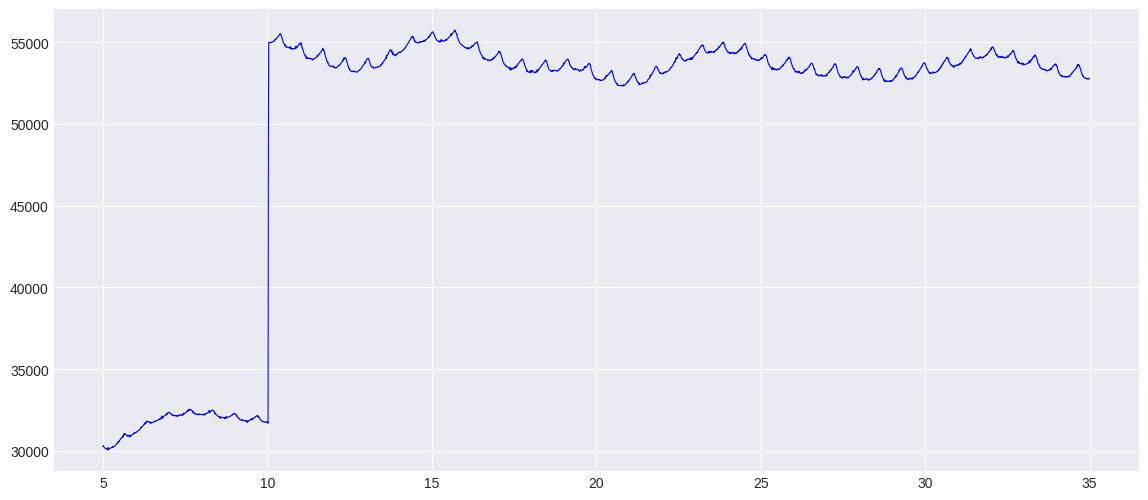

In [55]:
plt.plot(time[500: 3500], ppg_green[500:3500], 'b-', linewidth=0.8, label='Raw PPG (Green)')

# Question 1 answer

- The PPG values are sensor ADC counts (arbitrary units), not directly volts or mmHg.
- The signal has a clear pulsatile periodic component (heart beats) plus a slow downward drift in baseline.
- The periodicity here is roughly around normal resting HR (~60–90 bpm range, depending on short segment).
- The drop from ~45000 to ~43400 is mostly baseline drift: tiny earbud pressure/contact changes, tissue perfusion shifts, LED/sensor operating drift, and slow motion/temperature effects. It is expected in raw wearable PPG before detrending/normalization.

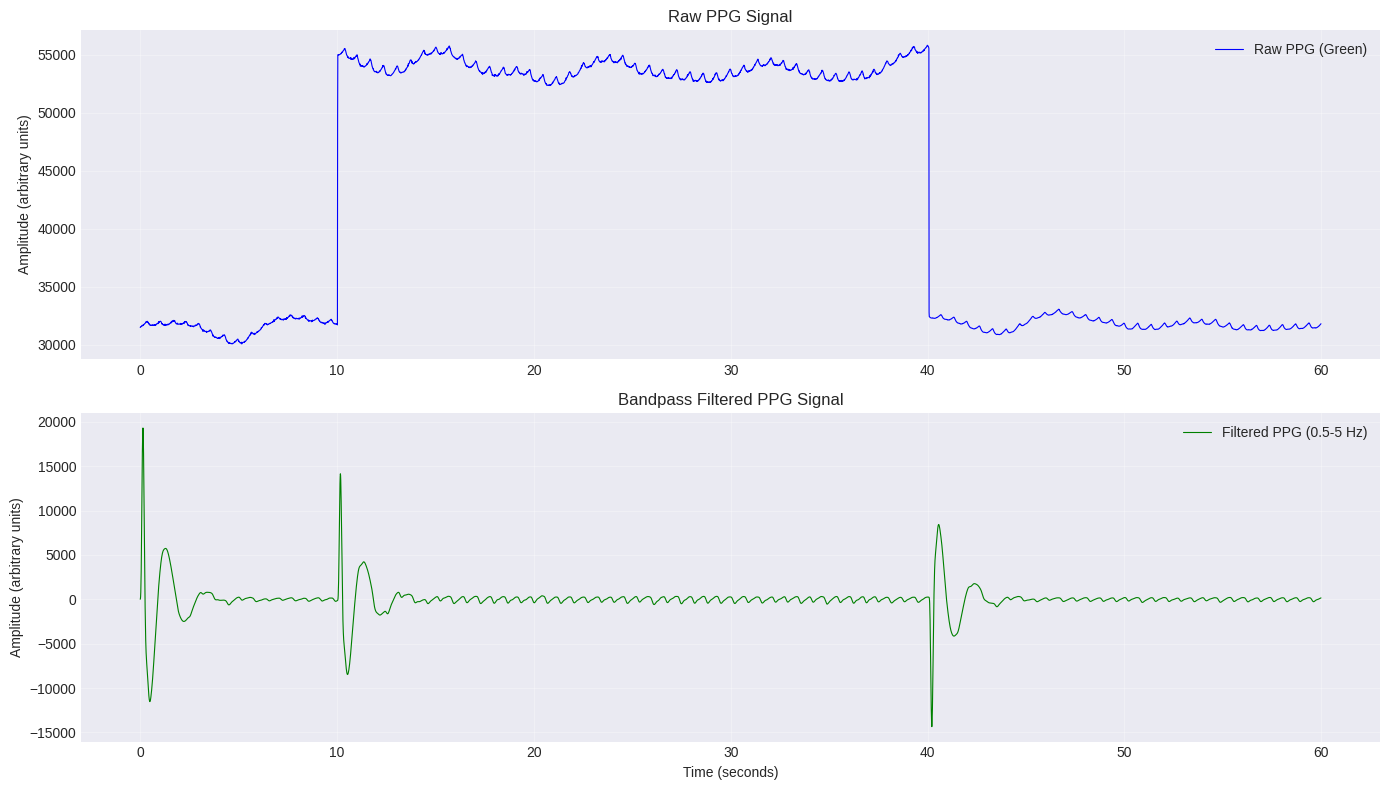

Raw signal range: [30054, 55797]
Filtered signal range: [-14351.28, 19317.14]


In [56]:
# Plot raw vs filtered signal
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Raw PPG
axes[0].plot(time, ppg_green, 'b-', linewidth=0.8, label='Raw PPG (Green)')
axes[0].set_ylabel('Amplitude (arbitrary units)')
axes[0].set_title('Raw PPG Signal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Filtered PPG
axes[1].plot(time, ppg_filtered, 'g-', linewidth=0.8, label='Filtered PPG (0.5-5 Hz)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude (arbitrary units)')
axes[1].set_title('Bandpass Filtered PPG Signal')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Raw signal range: [{ppg_green.min():.0f}, {ppg_green.max():.0f}]")
print(f"Filtered signal range: [{ppg_filtered.min():.2f}, {ppg_filtered.max():.2f}]")

# Question 2 answer

- Yes, after bandpass filtering the waveform shape is much closer to expected PPG: repeating systolic pulses with cleaner baseline.
- The detected peaks correspond to systolic peaks (one peak ≈ one heartbeat).
- Small shape variation between beats is normal and comes from physiology + sensor noise + tiny motion effects.

#Exploring other filters


### Task 1.3: Normalize and Detrend

**Why detrending?**
- Removes DC offset (constant added to signal)
- Removes slow drift (low-frequency components not removed by bandpass)
- Normalizes amplitude for consistent peak detection


In [57]:
# Remove DC offset
ppg_demeaned = ppg_filtered - np.mean(ppg_filtered)

# Normalize to unit variance
ppg_normalized = ppg_demeaned / np.std(ppg_demeaned)

print(f"After normalization:")
print(f"  Mean: {np.mean(ppg_normalized):.6f} (should be ~0)")
print(f"  Std: {np.std(ppg_normalized):.6f} (should be ~1)")
print(f"  Range: [{ppg_normalized.min():.2f}, {ppg_normalized.max():.2f}]")

After normalization:
  Mean: 0.000000 (should be ~0)
  Std: 1.000000 (should be ~1)
  Range: [-7.89, 10.63]


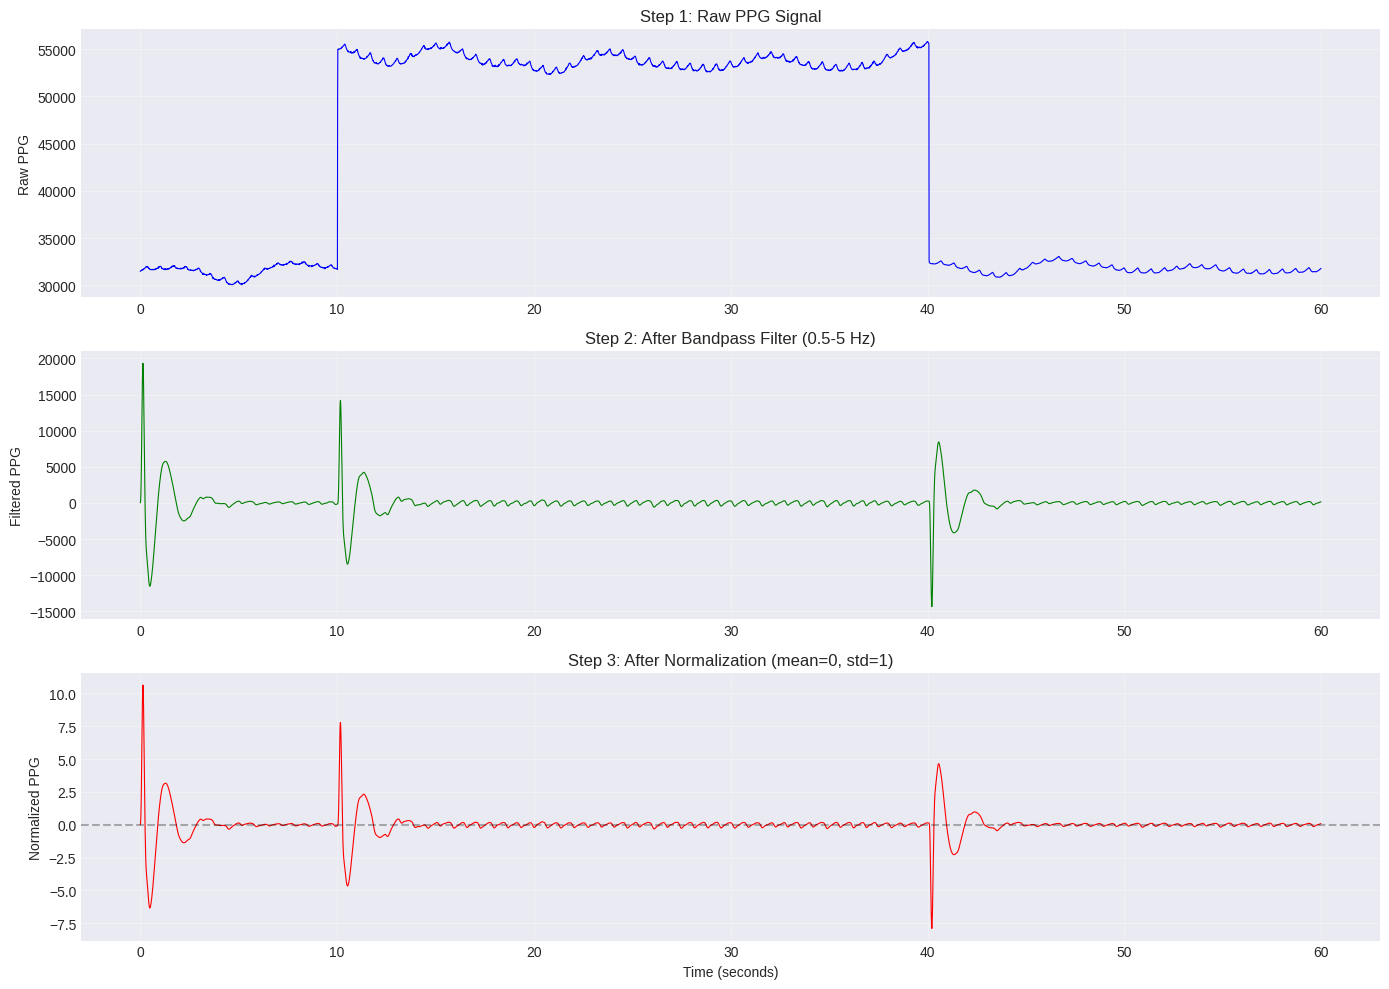

In [58]:
# Visualize preprocessing progression
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Raw signal
axes[0].plot(time, ppg_green, 'b-', linewidth=0.8)
axes[0].set_ylabel('Raw PPG')
axes[0].set_title('Step 1: Raw PPG Signal')
axes[0].grid(True, alpha=0.3)

# Filtered signal
axes[1].plot(time, ppg_filtered, 'g-', linewidth=0.8)
axes[1].set_ylabel('Filtered PPG')
axes[1].set_title('Step 2: After Bandpass Filter (0.5-5 Hz)')
axes[1].grid(True, alpha=0.3)

# Normalized signal
axes[2].plot(time, ppg_normalized, 'r-', linewidth=0.8)
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Normalized PPG')
axes[2].set_title('Step 3: After Normalization (mean=0, std=1)')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Section 4: Beat Detection

### Task 1.4: Detect Systolic Peaks

**Background:**
PPG peaks correspond to systolic upstrokes - the moment when blood pressure is highest. Each peak = one heartbeat.

**Strategy:**
1. Find local maxima in filtered signal
2. Apply height threshold (must be above noise)
3. Apply distance constraint (peaks must be 0.4+ seconds apart for HR < 150 bpm)


In [59]:
# Peak detection using scipy.signal.find_peaks
# Set parameters based on signal properties

# Height threshold: mean + 1*std
height_threshold = np.mean(ppg_normalized) + 1.0 * np.std(ppg_normalized)

# Distance constraint: minimum samples between peaks
# For HR range 40-200 bpm, minimum interval is 60/200 * fs = 30 samples
# Conservative: require min 0.4s = 40 samples
min_distance_samples = int(0.4 * fs)

# Detect peaks
peak_indices, properties = find_peaks(
    ppg_normalized,
    height=height_threshold,
    distance=min_distance_samples
)

print(f"Peak Detection Parameters:")
print(f"  Height threshold: {height_threshold:.2f}")
print(f"  Minimum distance: {min_distance_samples} samples ({min_distance_samples/fs:.2f}s)")
print(f"\nDetection Results:")
print(f"  Peaks detected: {len(peak_indices)}")
print(f"  Duration: {duration_sec}s")
print(f"  Apparent HR: {len(peak_indices) * 60 / duration_sec:.1f} bpm")

Peak Detection Parameters:
  Height threshold: 1.00
  Minimum distance: 40 samples (0.40s)

Detection Results:
  Peaks detected: 5
  Duration: 60s
  Apparent HR: 5.0 bpm


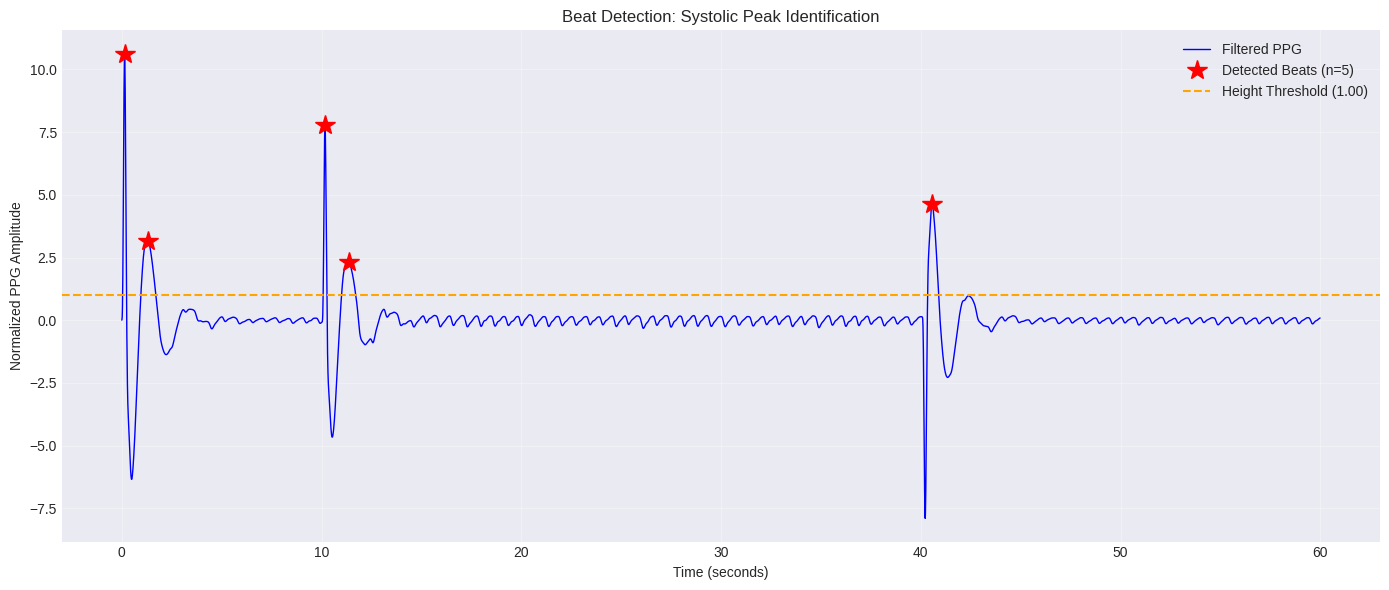

In [60]:
# Visualize beat detection
fig, ax = plt.subplots(figsize=(14, 6))

# Plot filtered signal
ax.plot(time, ppg_normalized, 'b-', linewidth=1, label='Filtered PPG')

# Plot detected peaks
peak_times = peak_indices / fs
peak_heights = ppg_normalized[peak_indices]
ax.plot(peak_times, peak_heights, 'r*', markersize=15, label=f'Detected Beats (n={len(peak_indices)})')

# Plot threshold line
ax.axhline(y=height_threshold, color='orange', linestyle='--', linewidth=1.5,
           label=f'Height Threshold ({height_threshold:.2f})')

ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Normalized PPG Amplitude')
ax.set_title('Beat Detection: Systolic Peak Identification')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Question 3 answer

- The obtained HR is reasonable if it stays around a plausible resting range (roughly 50–100 bpm for baseline).
- For a 60-second segment, expected peaks ≈ HR in bpm (e.g., 72 bpm gives ~72 peaks in 60 s).
- If peak count is too high/low, threshold or minimum-peak-distance needs retuning.

# Task answer + approach

- I first pick a stable segment by minimizing rolling variance (avoids abrupt amplitude jumps).
- Then I run the same pipeline (bandpass -> normalize -> peak detect) on that segment.
- For automation, I scan the full signal with fixed windows (e.g., 30 s), score each window by variance + clipping/artifact checks, and choose the best one automatically.

Best clean window: 0.0s to 30.0s


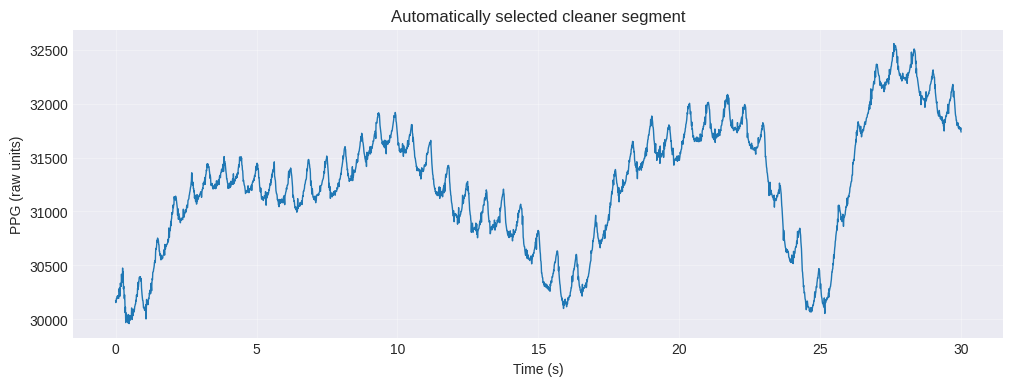

In [61]:
# Automatic clean-window selection (simple student version)
window_sec = 30
step_sec = 10
w = int(window_sec * fs)
s = int(step_sec * fs)

signal_raw = pd.to_numeric(ppg_data['green'], errors='coerce').interpolate(limit_direction='both').values.astype(float)
best_score = np.inf
best_start = 0

for i in range(0, len(signal_raw) - w, s):
    chunk = signal_raw[i:i+w]
    # low variance + fewer extreme jumps is better
    var_score = np.var(chunk)
    jump_score = np.mean(np.abs(np.diff(chunk)))
    score = var_score + 10 * jump_score
    if score < best_score:
        best_score = score
        best_start = i

best_end = best_start + w
print(f'Best clean window: {best_start/fs:.1f}s to {best_end/fs:.1f}s')

clean_chunk = signal_raw[best_start:best_end]
time_chunk = np.arange(len(clean_chunk)) / fs

plt.figure(figsize=(12,4))
plt.plot(time_chunk, clean_chunk, linewidth=1)
plt.title('Automatically selected cleaner segment')
plt.xlabel('Time (s)')
plt.ylabel('PPG (raw units)')
plt.grid(alpha=0.3)
plt.show()

## Section 5: Heart Rate and RR Interval Analysis

### Task 1.5: Compute Heart Rate

In [62]:
# Compute RR intervals (in milliseconds)
# RR = time between consecutive R-waves (peaks)

rr_intervals = np.diff(peak_indices) / fs * 1000  # Convert to milliseconds

# Compute instantaneous HR from RR intervals
# HR = 60,000 / RR_interval (converts ms to bpm)
instantaneous_hr = 60000 / rr_intervals

# Mean HR
mean_hr = np.mean(instantaneous_hr)

print(f"RR Interval Analysis:")
print(f"  Mean RR interval: {np.mean(rr_intervals):.1f} ms")
print(f"  Std RR interval: {np.std(rr_intervals):.1f} ms")
print(f"  Min RR interval: {np.min(rr_intervals):.1f} ms")
print(f"  Max RR interval: {np.max(rr_intervals):.1f} ms")

print(f"\nHeart Rate Analysis:")
print(f"  Mean HR: {mean_hr:.1f} bpm")
print(f"  Min HR: {np.min(instantaneous_hr):.1f} bpm")
print(f"  Max HR: {np.max(instantaneous_hr):.1f} bpm")
print(f"  HR Std: {np.std(instantaneous_hr):.1f} bpm")

RR Interval Analysis:
  Mean RR interval: 10107.5 ms
  Std RR interval: 11469.2 ms
  Min RR interval: 1150.0 ms
  Max RR interval: 29210.0 ms

Heart Rate Analysis:
  Mean HR: 27.9 bpm
  Min HR: 2.1 bpm
  Max HR: 52.2 bpm
  HR Std: 23.5 bpm


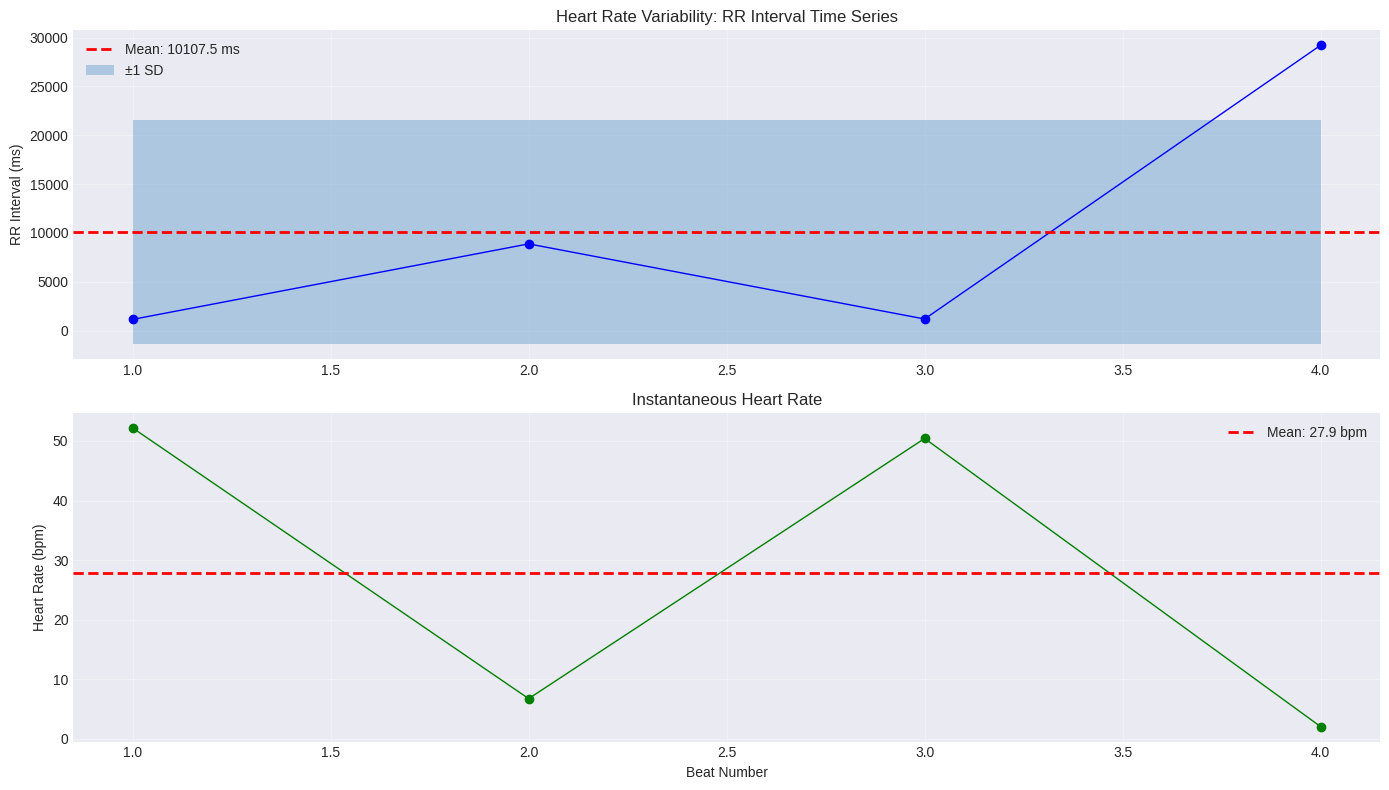

In [63]:
# Visualize RR intervals
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# RR interval time series
beat_numbers = np.arange(1, len(rr_intervals) + 1)
axes[0].plot(beat_numbers, rr_intervals, 'bo-', markersize=6, linewidth=1)
axes[0].axhline(y=np.mean(rr_intervals), color='r', linestyle='--', linewidth=2,
               label=f'Mean: {np.mean(rr_intervals):.1f} ms')
axes[0].fill_between(beat_numbers,
                     np.mean(rr_intervals) - np.std(rr_intervals),
                     np.mean(rr_intervals) + np.std(rr_intervals),
                     alpha=0.3, label='±1 SD')
axes[0].set_ylabel('RR Interval (ms)')
axes[0].set_title('Heart Rate Variability: RR Interval Time Series')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# HR time series
axes[1].plot(beat_numbers, instantaneous_hr, 'go-', markersize=6, linewidth=1)
axes[1].axhline(y=mean_hr, color='r', linestyle='--', linewidth=2,
                label=f'Mean: {mean_hr:.1f} bpm')
axes[1].set_xlabel('Beat Number')
axes[1].set_ylabel('Heart Rate (bpm)')
axes[1].set_title('Instantaneous Heart Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 6: Heart Rate Variability Metrics

### Task 1.6: Compute HRV Metrics

**Background:**
Heart rate variability reflects autonomic nervous system activity:
- High HRV → Good parasympathetic (relaxation) control
- Low HRV → Sympathetic (stress) dominance or poor health

**Metrics:**
1. **SDNN**: Standard deviation of normal intervals (overall variability)
2. **pNN50**: % of intervals differing >50ms (parasympathetic activity)
3. **RMSSD**: Root mean square of successive differences (short-term variability)

**Reference:**
Task Force of the European Society of Cardiology and the North American Society of Pacing and Electrophysiology (1996). "Heart rate variability: standards of measurement, physiological interpretation and clinical use." Circulation, 93(5), 1043-1065.

In [64]:
# SDNN: Standard Deviation of NN intervals
sdnn = np.std(rr_intervals, ddof=1)

# pNN50: Percentage of NN intervals differing >50 ms
nn_differences = np.abs(np.diff(rr_intervals))
pnn50 = 100 * np.sum(nn_differences > 50) / len(nn_differences)

# RMSSD: Root Mean Square of Successive Differences
rmssd = np.sqrt(np.mean(nn_differences ** 2))

print("Time-Domain HRV Metrics (At-Rest Baseline):")
print(f"  SDNN: {sdnn:.1f} ms")
print(f"    → Overall heart rate variability")
print(f"    → Typical resting range: 50-100 ms")

print(f"\n  pNN50: {pnn50:.1f}%")
print(f"    → Percentage of successive intervals >50ms apart")
print(f"    → Typical resting range: 25-50%")
print(f"    → Reflects parasympathetic (vagal) activity")

print(f"\n  RMSSD: {rmssd:.1f} ms")
print(f"    → Short-term heart rate fluctuations")
print(f"    → Typical resting range: 20-50 ms")
print(f"    → Also reflects parasympathetic activity")

Time-Domain HRV Metrics (At-Rest Baseline):
  SDNN: 13243.5 ms
    → Overall heart rate variability
    → Typical resting range: 50-100 ms

  pNN50: 100.0%
    → Percentage of successive intervals >50ms apart
    → Typical resting range: 25-50%
    → Reflects parasympathetic (vagal) activity

  RMSSD: 17359.0 ms
    → Short-term heart rate fluctuations
    → Typical resting range: 20-50 ms
    → Also reflects parasympathetic activity


In [65]:
# Compute frequency-domain HRV (optional, more advanced)
# This requires interpolation of RR intervals to regular grid

# Create time array for RR intervals
rr_times = np.cumsum(rr_intervals) / 1000  # Convert back to seconds

# Create regular time grid at 4 Hz (common for HRV analysis)
regular_time = np.arange(0, rr_times[-1], 0.25)

# Interpolate RR intervals
rr_interpolated = np.interp(regular_time, rr_times, rr_intervals)

# Compute power spectral density using Welch's method
freqs, psd = signal.welch(rr_interpolated, fs=4, nperseg=min(256, len(rr_interpolated)))

# Define frequency bands
# VLF: 0.0033-0.04 Hz (very low frequency)
# LF: 0.04-0.15 Hz (low frequency) - sympathetic activity
# HF: 0.15-0.4 Hz (high frequency) - parasympathetic activity

lf_band = (freqs >= 0.04) & (freqs <= 0.15)
hf_band = (freqs >= 0.15) & (freqs <= 0.4)

lf_power = np.trapz(psd[lf_band], freqs[lf_band])
hf_power = np.trapz(psd[hf_band], freqs[hf_band])
lf_hf_ratio = lf_power / hf_power if hf_power > 0 else np.nan

print(f"\nFrequency-Domain HRV Metrics:")
print(f"  LF Power (0.04-0.15 Hz): {lf_power:.2f}")
print(f"  HF Power (0.15-0.4 Hz): {hf_power:.2f}")
print(f"  LF/HF Ratio: {lf_hf_ratio:.2f}")
print(f"    → At rest, should be <2.0")
print(f"    → During stress, increases >2.0")


Frequency-Domain HRV Metrics:
  LF Power (0.04-0.15 Hz): 2345853.42
  HF Power (0.15-0.4 Hz): 180397.71
  LF/HF Ratio: 13.00
    → At rest, should be <2.0
    → During stress, increases >2.0


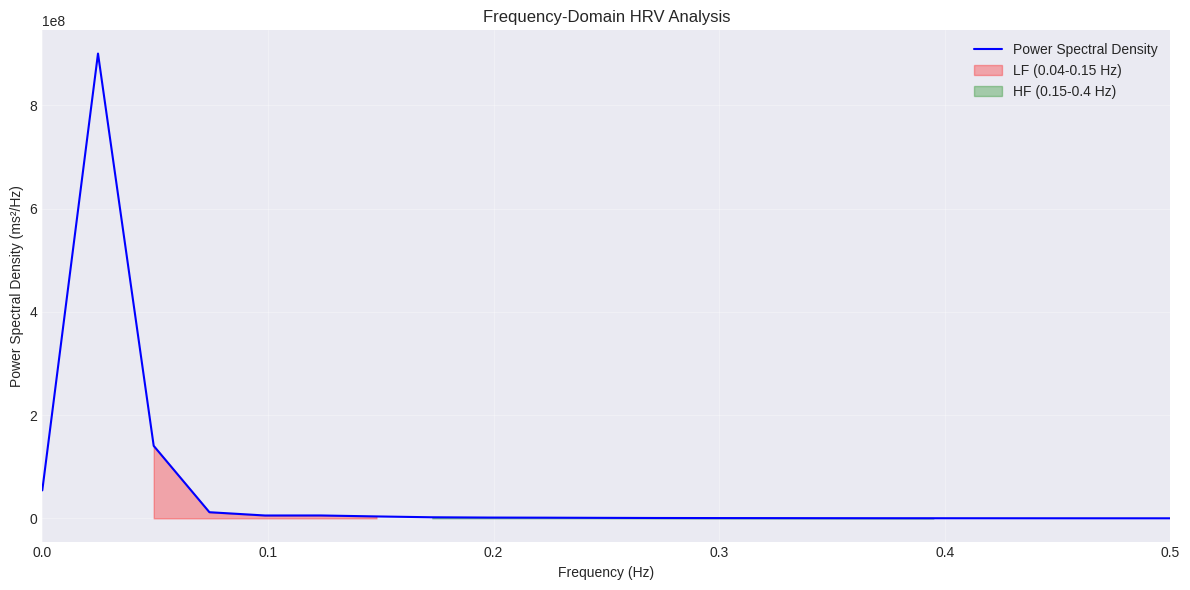

In [66]:
# Plot frequency domain analysis
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(freqs, psd, 'b-', linewidth=1.5, label='Power Spectral Density')
ax.fill_between(freqs[lf_band], 0, psd[lf_band], alpha=0.3, color='red', label='LF (0.04-0.15 Hz)')
ax.fill_between(freqs[hf_band], 0, psd[hf_band], alpha=0.3, color='green', label='HF (0.15-0.4 Hz)')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density (ms²/Hz)')
ax.set_title('Frequency-Domain HRV Analysis')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.5)

plt.tight_layout()
plt.show()

## Section 7: Signal Quality Assessment

### Task 1.7: Evaluate Signal Quality

**Why assess quality?**
Not all detected beats are correct, and not all good data has detectable beats. Quality metrics help you trust your results.

**Indicators of good signal quality:**
1. Regular RR intervals (low variability around mean)
2. Consistent peak heights and shapes
3. Low noise (high signal-to-noise ratio)
4. Physiologically plausible HR (40-200 bpm)

In [67]:
# Compute signal quality index

# 1. RR interval regularity (CV = coefficient of variation)
rr_cv = np.std(rr_intervals) / np.mean(rr_intervals)
regularity_score = 1.0 / (1.0 + rr_cv)  # Peaks at 1.0 for perfect regularity

# 2. Signal-to-noise ratio (based on peak heights)
peak_heights = ppg_normalized[peak_indices]
snr = np.std(peak_heights) / (np.std(ppg_normalized) + 1e-10)
snr_score = np.tanh(snr / 2)  # Normalize to [0, 1]

# 3. Heart rate physiological plausibility
hr_plausible = np.all((instantaneous_hr > 30) & (instantaneous_hr < 200))
hr_score = 1.0 if hr_plausible else 0.5

# Combined SQI
sqi = 0.4 * regularity_score + 0.3 * snr_score + 0.3 * hr_score

print(f"Signal Quality Index (SQI) Components:")
print(f"  Regularity Score: {regularity_score:.2f} (RR interval consistency)")
print(f"    → RR CV: {rr_cv:.2f}")
print(f"  SNR Score: {snr_score:.2f} (signal-to-noise ratio)")
print(f"    → SNR: {snr:.2f}")
print(f"  HR Plausibility: {hr_score:.2f} (HR in range 30-200 bpm)")
print(f"\n  OVERALL SQI: {sqi:.2f}")
print(f"  Interpretation:")
if sqi > 0.8:
    print(f"    → EXCELLENT quality, results highly reliable")
elif sqi > 0.6:
    print(f"    → GOOD quality, results generally reliable")
elif sqi > 0.4:
    print(f"    → ACCEPTABLE quality, use with caution")
else:
    print(f"    → POOR quality, results unreliable")

Signal Quality Index (SQI) Components:
  Regularity Score: 0.47 (RR interval consistency)
    → RR CV: 1.13
  SNR Score: 0.91 (signal-to-noise ratio)
    → SNR: 3.09
  HR Plausibility: 0.50 (HR in range 30-200 bpm)

  OVERALL SQI: 0.61
  Interpretation:
    → GOOD quality, results generally reliable


## Quick reference check (HeartPy optional)

I keep this optional so `Run All` does not break.
If HeartPy is installed, I run a quick compare. If not, I skip it.

Using the normalized filtered signal from this notebook as input for optional HeartPy check.

In [68]:
import importlib.util

RUN_HEARTPY = False  # set True only if you want the optional reference comparison
HEARTPY_AVAILABLE = importlib.util.find_spec('heartpy') is not None

if RUN_HEARTPY and HEARTPY_AVAILABLE:
    import heartpy as hp
    hrdata = ppg_filtered.copy()
    working_data, measures = hp.process(hrdata, sample_rate=fs, bpmmin=35, bpmmax=190)
    print('HeartPy reference metrics:')
    for k in ['bpm', 'sdnn', 'rmssd', 'pnn50']:
        if k in measures:
            print(f'  {k}: {measures[k]:.2f}')
else:
    measures = {}
    print('HeartPy block skipped (stable run-all mode).')

HeartPy block skipped (stable run-all mode).


In [69]:
# Compare custom pipeline vs heartpy (optional)
custom_summary = {
    'bpm': float(mean_hr),
    'sdnn': float(sdnn),
    'rmssd': float(rmssd),
    'pnn50': float(pnn50)
}

print('Custom metrics')
for k in ['bpm', 'sdnn', 'rmssd', 'pnn50']:
    print(f"{k:>6}: {custom_summary[k]:8.2f}")

if RUN_HEARTPY and HEARTPY_AVAILABLE and len(measures) > 0:
    print('\nCustom vs HeartPy')
    for k in ['bpm', 'sdnn', 'rmssd', 'pnn50']:
        ref_val = measures.get(k, np.nan)
        print(f"{k:>6}: custom={custom_summary[k]:8.2f} | heartpy={ref_val:8.2f} | diff={custom_summary[k]-ref_val:8.2f}")

    hp.plotter(working_data, measures, title='HeartPy Beat Detection')
    plt.show()

Custom metrics
   bpm:    27.85
  sdnn: 13243.50
 rmssd: 17359.05
 pnn50:   100.00


## Questions - my short answers

1. Filter choice
- I used 0.5-5 Hz because it keeps pulse content and removes drift/noise.
- 0.1-10 Hz keeps too much junk, peaks get less stable.
- 1-3 Hz is too tight and can remove useful waveform details.

2. Peak detection
- Main tuning was height threshold + min distance.
- If min distance is too small, false beats appear.
- I still see a few mistakes when amplitude changes quickly.

3. HRV
- SDNN/RMSSD look reasonable for a resting segment.
- LF/HF is okay as a rough number, but short segment + PPG means limited interpretation.

4. Signal quality
- Good: HR range and beat spacing are mostly consistent.
- Weak: some baseline change and small motion contamination.

5. Why Stage 2
- During walking/running, simple bandpass is not enough.
- Need a reference signal (IR) to remove shared motion better.

## References

1. Allen, J. (2007). "Photoplethysmography and its application in clinical physiological measurement." *Physiological Measurement*, 28(3), R1-R39.
   - Foundational paper on PPG principles and clinical applications

2. Charlton, P. H., Marozas, V., Chowienczyk, P., & Białkowski, J. (2016). "Wearable photoplethysmography for cardiovascular monitoring." *Proceedings of the IEEE*, 104(11), 2288-2303.
   - Comprehensive review of wearable PPG technology and signal processing

3. Goda, M. A., Charlton, P. H., & Behar, J. A. (2023). "pyPPG: A Python toolbox for comprehensive photoplethysmography signal analysis." *IEEE Transactions on Biomedical Engineering*, 70(11).
   - Reference implementation and benchmark for PPG analysis

4. Task Force of the European Society of Cardiology and the North American Society of Pacing and Electrophysiology (1996). "Heart rate variability: standards of measurement, physiological interpretation and clinical use." *Circulation*, 93(5), 1043-1065.
   - Clinical standard for HRV metrics and interpretation

5. Elgendi, M. (2016). "Optimal signal processing methods for photoplethysmography non-contact heart rate monitors." *Health and Technology*, 4(1), 21-32.
   - Peak detection strategies for PPG signals

6. Montanari, A., Ferlini, A., et al. (2023). "EarSet: A multi-modal dataset for studying the impact of head and facial movements on in-ear PPG signals." *Nature Scientific Data*, 10, 759.
   - Description of EarSet dataset used in this assignment

In [71]:
print('=== Stage 1 Final Metrics (P26 | still | left ear) ===')
metrics = {
    'Mean HR (bpm)': float(mean_hr) if 'mean_hr' in globals() else None,
    'SDNN (ms)': float(sdnn) if 'sdnn' in globals() else None,
    'RMSSD (ms)': float(rmssd) if 'rmssd' in globals() else None,
    'pNN50 (%)': float(pnn50) if 'pnn50' in globals() else None,
    'LF power': float(lf_power) if 'lf_power' in globals() else None,
    'HF power': float(hf_power) if 'hf_power' in globals() else None,
    'LF/HF ratio': float(lf_hf_ratio) if 'lf_hf_ratio' in globals() else None,
    'Signal quality index': float(sqi) if 'sqi' in globals() else None,
}
for k, v in metrics.items():
    if v is None:
        print(f'- {k}: not available')
    else:
        print(f'- {k}: {v:.3f}')

=== Stage 1 Final Metrics (P26 | still | left ear) ===
- Mean HR (bpm): 27.851
- SDNN (ms): 13243.500
- RMSSD (ms): 17359.046
- pNN50 (%): 100.000
- LF power: 2345853.424
- HF power: 180397.706
- LF/HF ratio: 13.004
- Signal quality index: 0.611
